In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print('Number of records:',df.shape[0])
print('Number of columns:',df.shape[1])

Number of records: 545
Number of columns: 13


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
for i in df.columns:
    print(df[i].value_counts())

price
4200000    17
3500000    17
4900000    12
5600000     9
5250000     9
           ..
2135000     1
1960000     1
1855000     1
1820000     1
1767150     1
Name: count, Length: 219, dtype: int64
area
6000    24
3000    14
4500    13
4000    11
6600     9
        ..
3360     1
1700     1
3649     1
2990     1
3620     1
Name: count, Length: 284, dtype: int64
bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64
bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64
stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64
mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64
prefarea
no     417
yes    128
Name

In [6]:
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes': 1, 'no': 0})
df['airconditioning'] = df['airconditioning'].map({'yes': 1, 'no': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':2, 'semi-furnished': 1, 'unfurnished': 0})

In [7]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2


C:\Users\shiv\AppData\Local\Temp\ipykernel_2616\2489636919.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax, layout=(3,5), alpha=0.5);


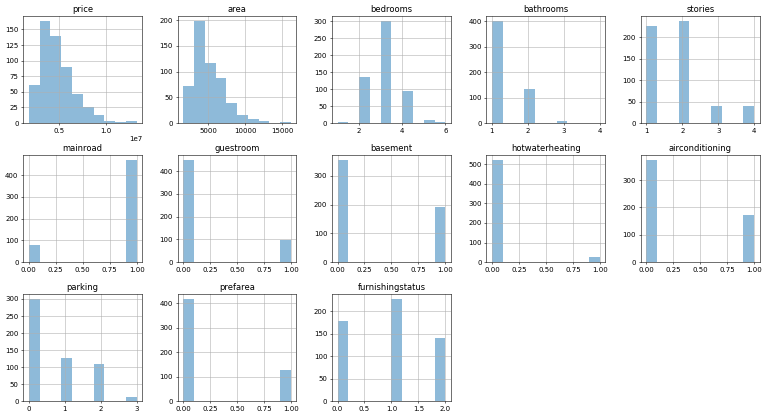

In [8]:
fig, ax = plt.subplots(figsize=(19,10), dpi=50);
df.hist(ax=ax, layout=(3,5), alpha=0.5);

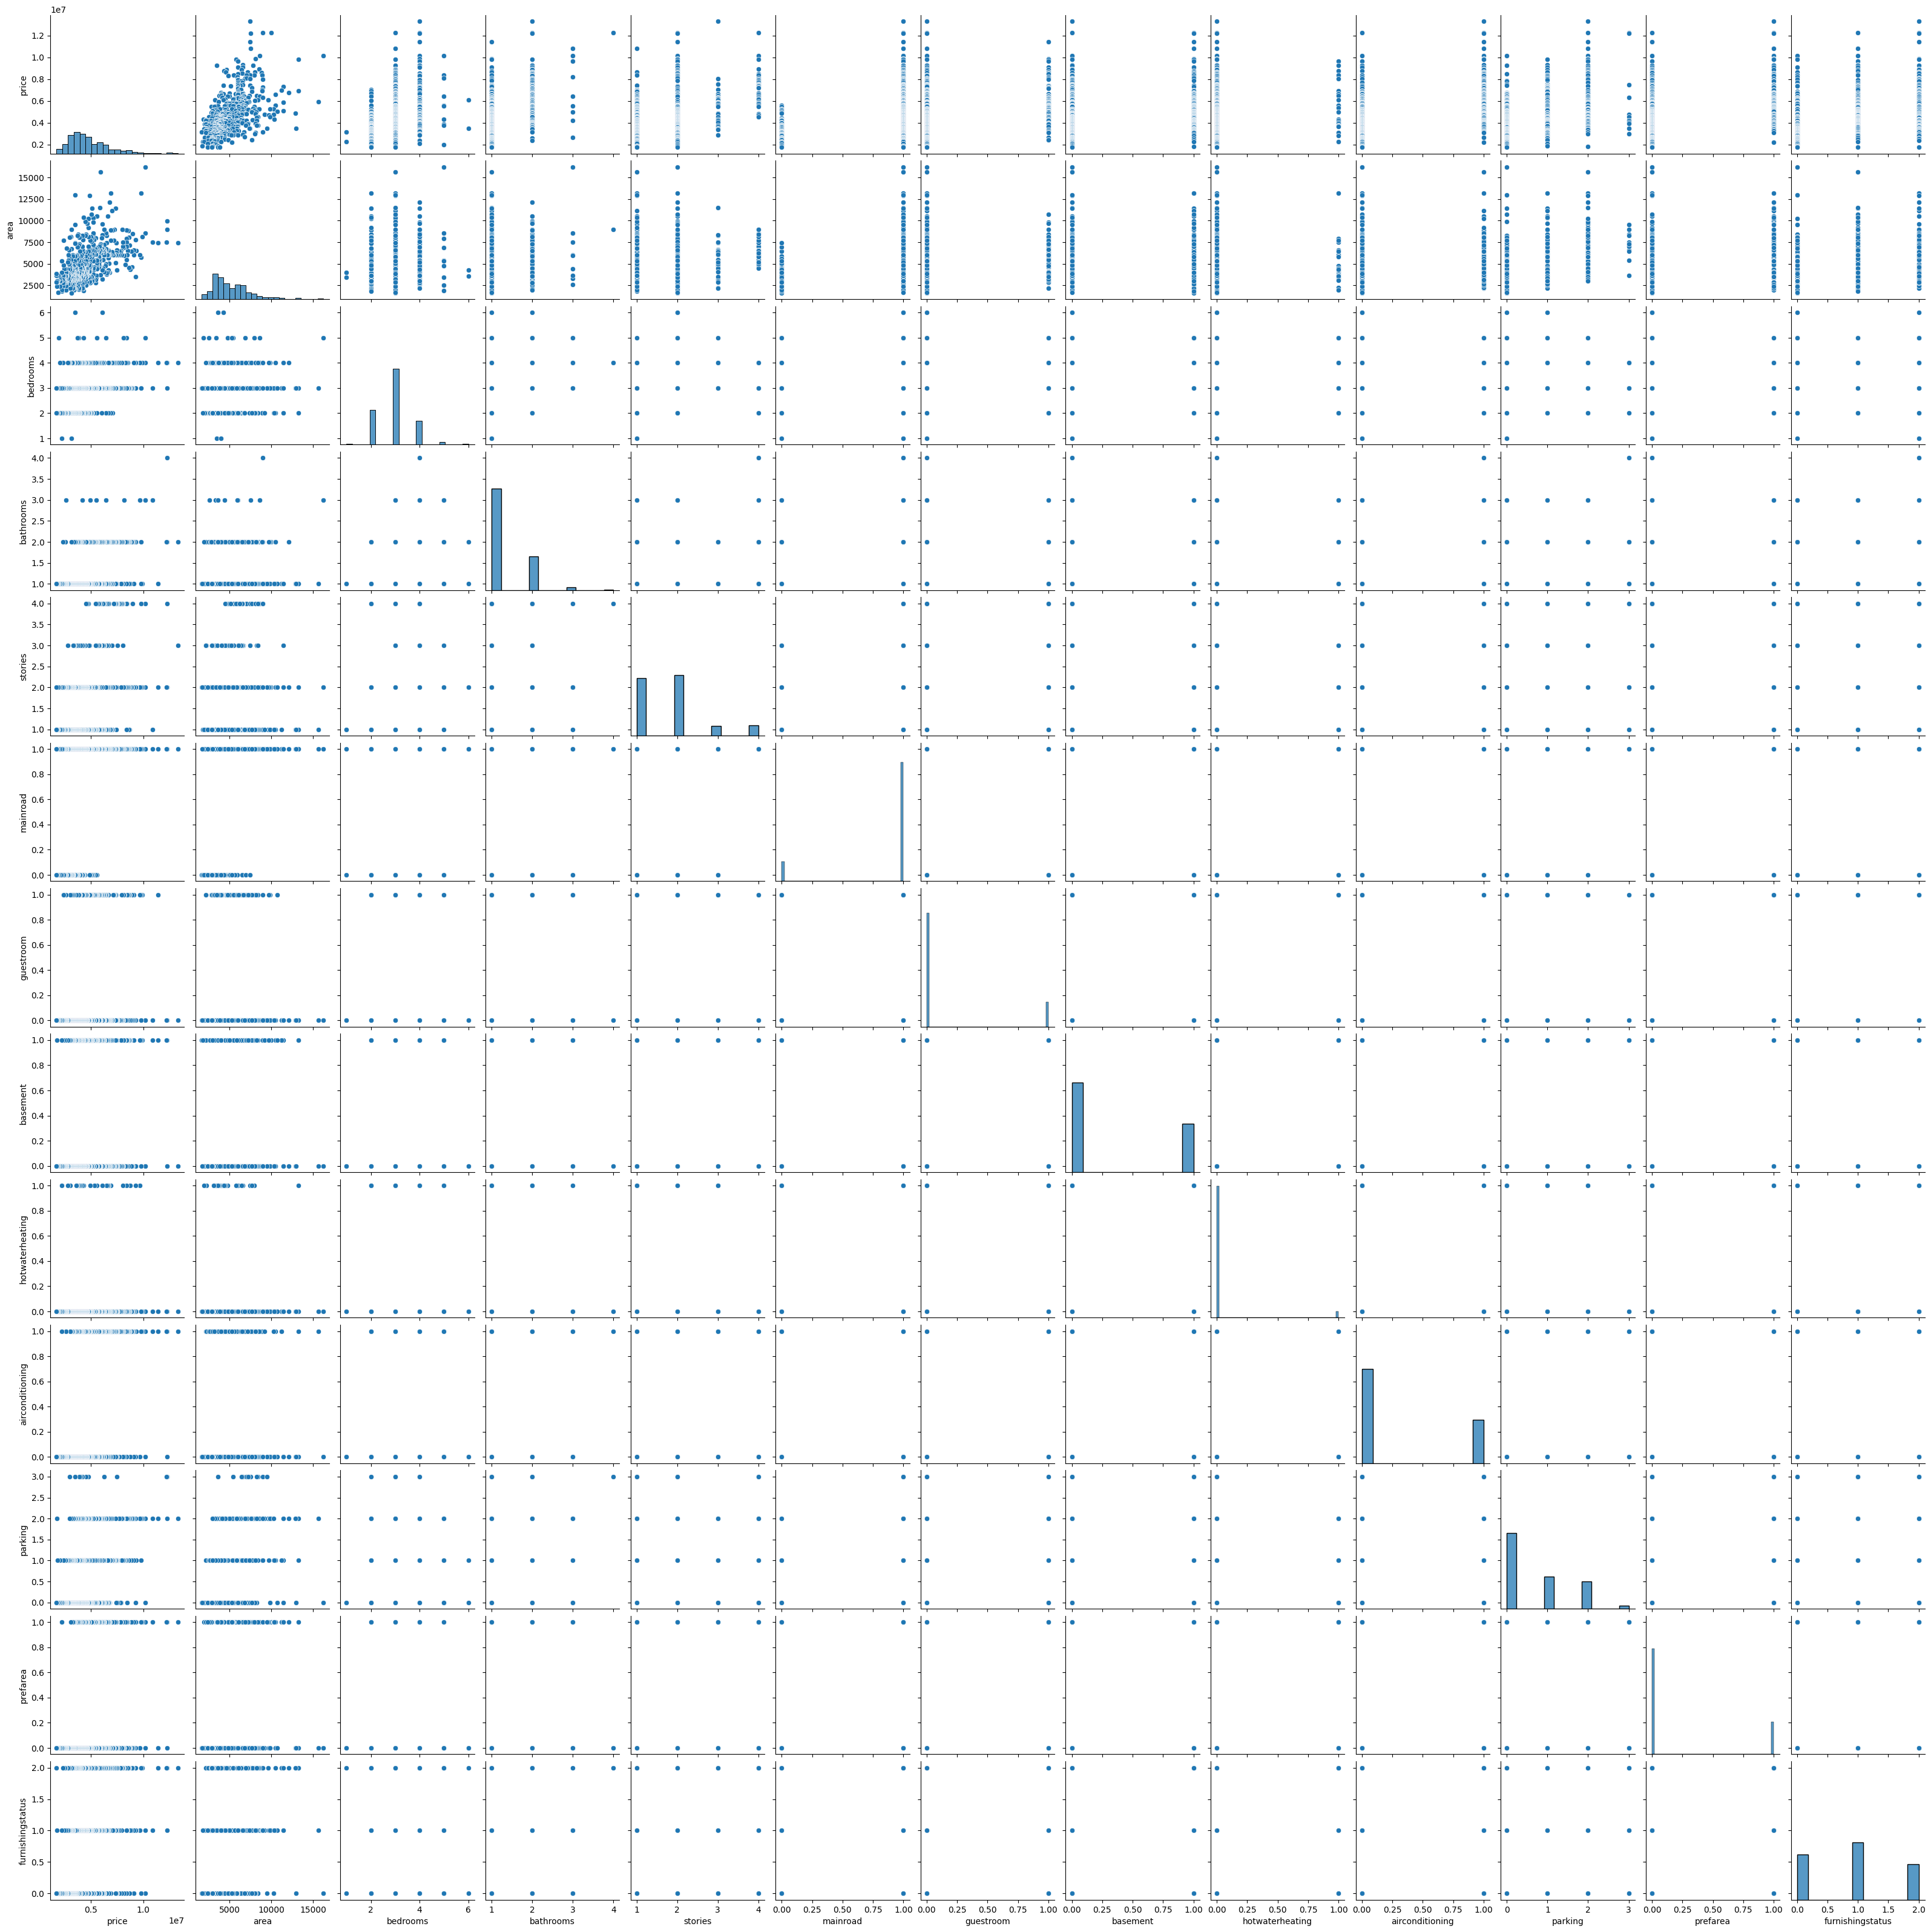

In [9]:
sns.pairplot(df)

<Axes: >

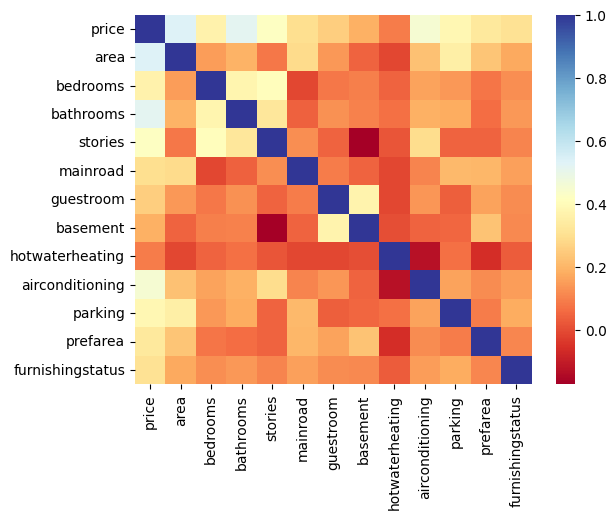

In [10]:
sns.heatmap(df.corr(numeric_only = True), cmap='RdYlBu')

In [11]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

<Axes: ylabel='area'>

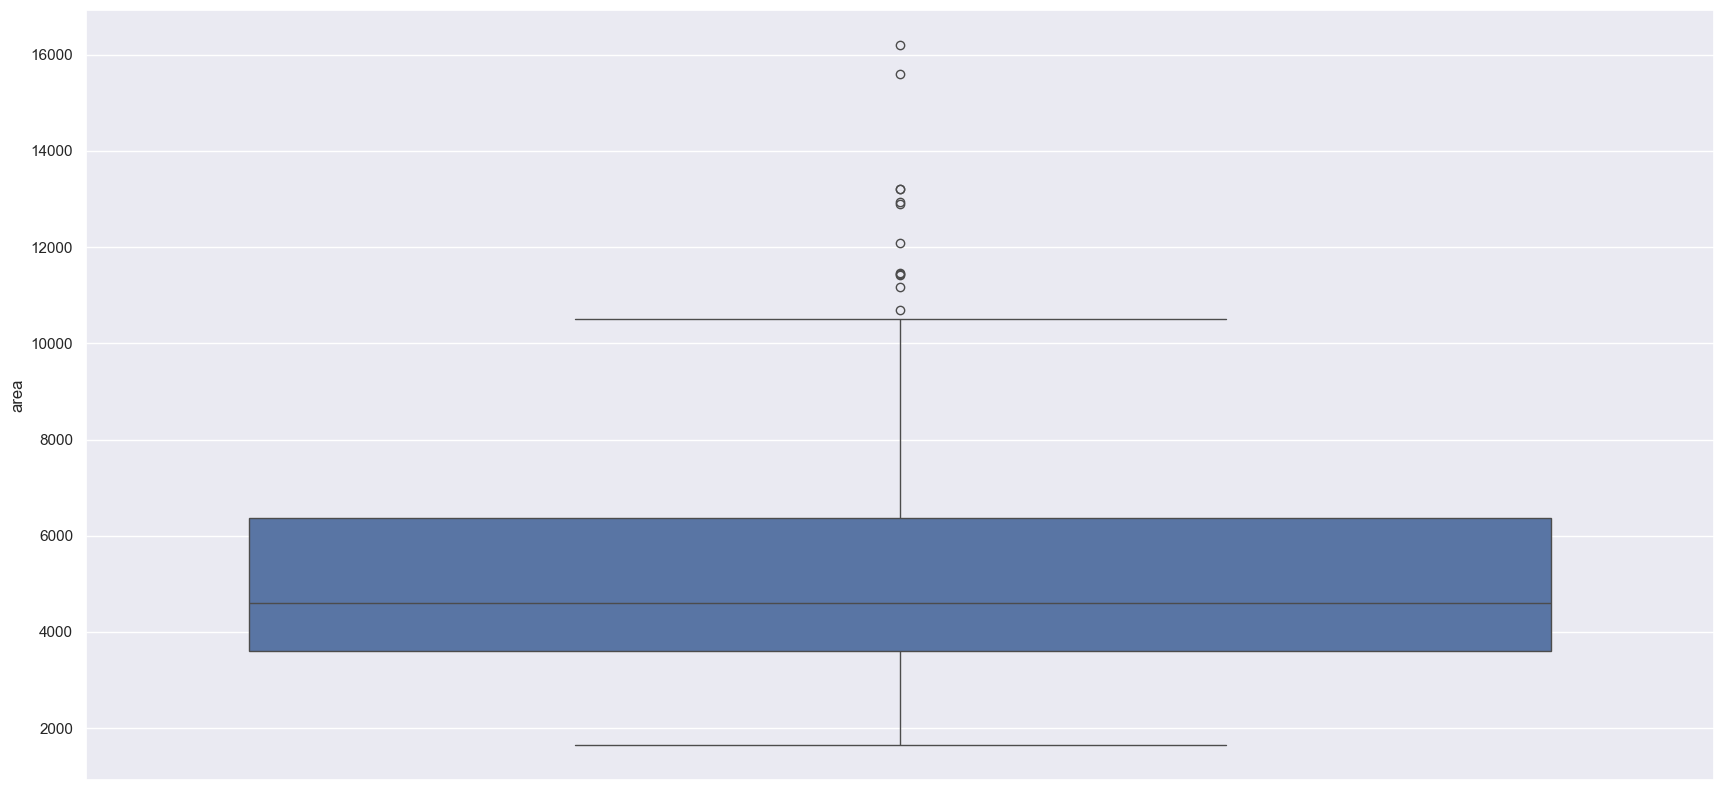

In [12]:
sns.set(rc={'figure.figsize':(21,10)})
sns.boxplot(data=df.iloc[:,1])

<Axes: >

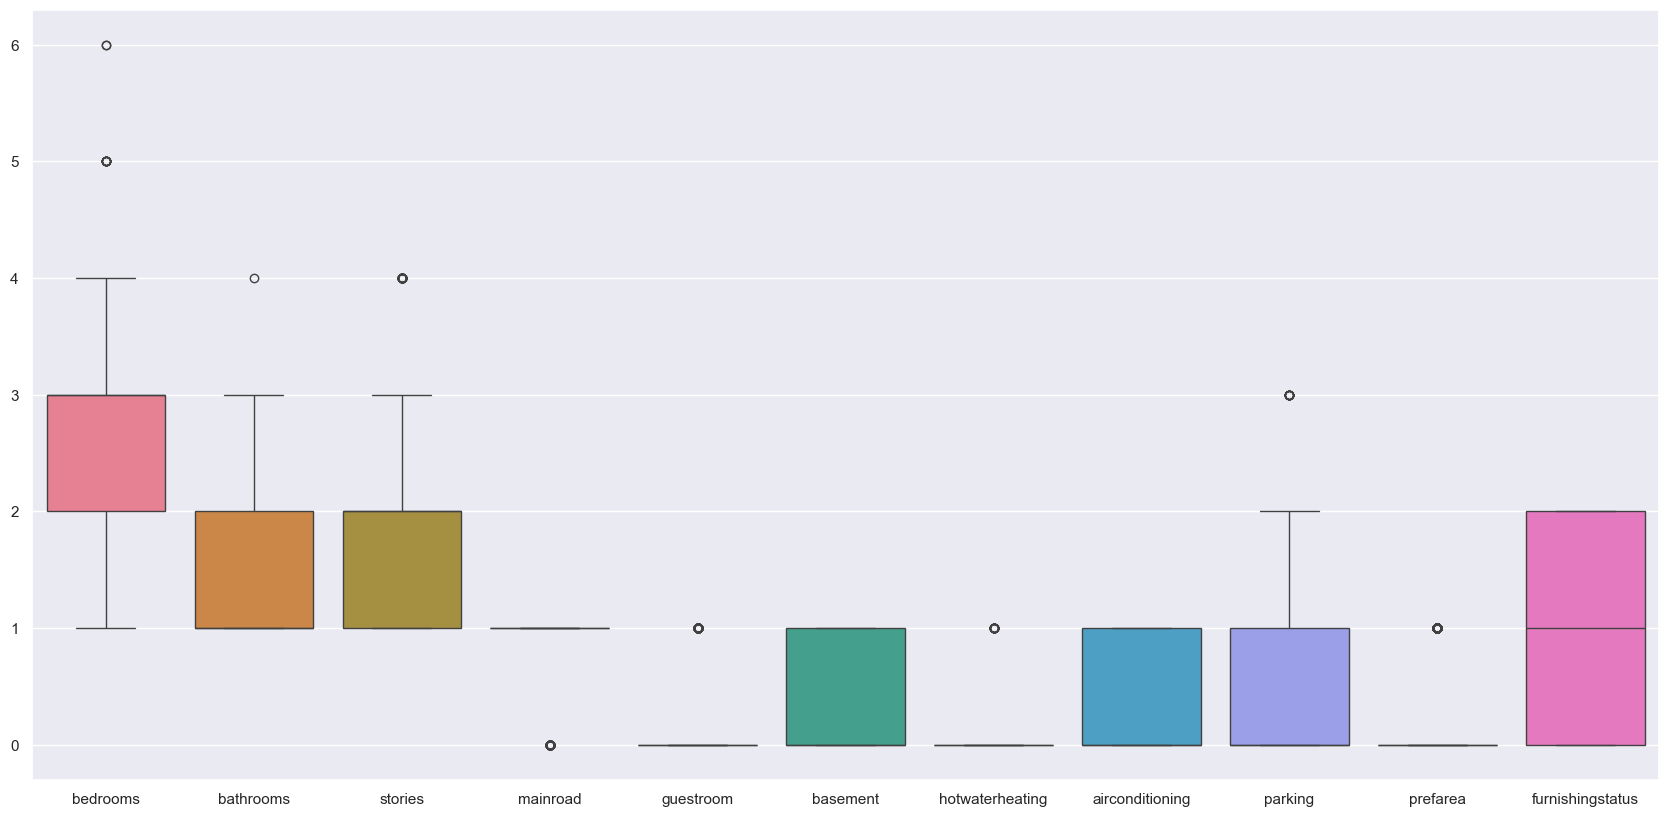

In [13]:
sns.set(rc={'figure.figsize':(21,10)})
sns.boxplot(data=df.iloc[:,2:])

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def normalize(X):
        print("Mean and Standard Deviation Before")
        print(X.mean(axis=0), X.std(axis=0))

        #**********************************************
        ##### TO DO: Standardize X part [feature wise scaling!!!!!]
        ##### and ensure that resultant data has mean around 0 and standard deviation 1 !!!
        sc=StandardScaler()
        XScaled = sc.fit_transform(X)
        #**********************************************

        print("Mean and Standard Deviation After")
        print(XScaled.mean(axis=0).round(4), XScaled.std(axis=0))
        return XScaled

In [15]:
from sklearn.model_selection import train_test_split

def splitTrainTest(X, Y, seed, splitRatio):
        #***************************************************************
        ######### SPLIT THE """"""XScaled""""""" AND """"""" Y """"""" into trainining and test partitions with 80%-20%split
        #<Hint: Fix a random state so that same partition is generated everytime>
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=splitRatio, random_state=seed)
        #****************************************************************
        print("Dimensions of Original Data:")
        print("Size(X):", X.shape, "; Size(Y)", Y.shape)
        print("Dimensions of Training Data:")
        print("Size(X_train):", X_train.shape, "; Size(Y_train)", Y_train.shape)
        print("Dimensions of Test Data:")
        print("Size(X_test):", X_test.shape, "; Size(Y_test)", Y_test.shape)
        return X_train, X_test, Y_train, Y_test


In [16]:
def plotRegressionLine(X, Y, w, b):
    plt.scatter(x = X, y = Y)
    plt.plot(X, w*X+b, 'g-')
    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.show()

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

features =  df.columns[1:] #['area', 'bedrooms', 'parking', 'basement', 'stories']#, 'bathrooms', 'stories']
#features =  df.columns[1] #******UNIVARIATE**********

X = df[features].values #Retrieving values in numpy array
#X = df[features].values.reshape(-1,1) #********UNIVARIATE*********

Y = df['price'].values #Retrieving value in numpy array
Y = Y.reshape((-1,1))

print("*************Normalization/Standardization*************")
XScaled = normalize(X)

*************Normalization/Standardization*************
Mean and Standard Deviation Before
[5.15054128e+03 2.96513761e+00 1.28623853e+00 1.80550459e+00
 8.58715596e-01 1.77981651e-01 3.50458716e-01 4.58715596e-02
 3.15596330e-01 6.93577982e-01 2.34862385e-01 9.30275229e-01] [2.16814915e+03 7.37386427e-01 5.02008423e-01 8.66696233e-01
 3.48314687e-01 3.82497298e-01 4.77113618e-01 2.09206500e-01
 4.64752931e-01 8.60794942e-01 4.23912780e-01 7.60673843e-01]
Mean and Standard Deviation After
[-0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0.  0.] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [18]:

def LinRegression(XScaled, Y):
    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(XScaled, Y, seed=2, splitRatio=0.2)

    #USE K-FOLD CROSS-VALIDATION
    #EXAMPLE- kf=KFold(n_splits=5, shuffle=True, random_state=2)
    #for train_index, test_index in kf.split(X,Y):
    # X_train=X[train_index]
    # X_test=X[test_index]
    # Y_train=Y[train_index]
    # Y_test=Y[test_index]
    # FIND MSE N R2 metrics for each fold n report av VALUE at end

    print("*************Learning/Fitting the model on training partition*************")
    LRModel = LinearRegression()
    LRModel.fit(X_train,Y_train)
    print('Features used: ', features)
    print("Weight/Slope W:", LRModel.coef_)
    print("Bias/Intercept B:", LRModel.intercept_)

    print("*************Plotting Regression MODEL Learned if univariate *************")
    if X.shape[1] == 1:
        plotRegressionLine(X_train, Y_train, LRModel.coef_, LRModel.intercept_)

    print("*************Evaluating performance of trained model on test partition*************")
    Y_pred = LRModel.predict(X_test)
    print('MAE:', metrics.mean_absolute_error(Y_test, Y_pred))
    print('MSE:', metrics.mean_squared_error(Y_test, Y_pred))
    print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
    print('R2 SCore:', metrics.r2_score(Y_test, Y_pred))

In [19]:
LinRegression(XScaled, Y)

*************Train-Test Split*************
Dimensions of Original Data:
Size(X): (545, 12) ; Size(Y) (545, 1)
Dimensions of Training Data:
Size(X_train): (436, 12) ; Size(Y_train) (436, 1)
Dimensions of Test Data:
Size(X_test): (109, 12) ; Size(Y_test) (109, 1)
*************Learning/Fitting the model on training partition*************
Features used:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')
Weight/Slope W: [[535675.14124709  46358.33391486 480382.73019223 390679.66032738
  134173.73105439 132789.81540368 190964.89530814 171502.82724489
  397431.63594083 235978.53329663 298261.19902787 208841.43438928]]
Bias/Intercept B: [4743692.54157346]
*************Plotting Regression MODEL Learned if univariate *************
*************Evaluating performance of trained model on test partition*************
MAE: 865891.4864066505
MSE: 1291

In [20]:
from sklearn.model_selection import KFold

print("*************K-Fold Cross Validation*************")

kf = KFold(n_splits=5, shuffle=True, random_state=2)

mse_list = []
r2_list = []

for train_index, test_index in kf.split(XScaled):

    X_train_k = XScaled[train_index]
    X_test_k = XScaled[test_index]
    Y_train_k = Y[train_index]
    Y_test_k = Y[test_index]

    model_k = LinearRegression()
    model_k.fit(X_train_k, Y_train_k)

    Y_pred_k = model_k.predict(X_test_k)

    mse_list.append(metrics.mean_squared_error(Y_test_k, Y_pred_k))
    r2_list.append(metrics.r2_score(Y_test_k, Y_pred_k))

print("Average K-Fold MSE:", np.mean(mse_list))
print("Average K-Fold R2:", np.mean(r2_list))

*************K-Fold Cross Validation*************
Average K-Fold MSE: 1192815031395.6665
Average K-Fold R2: 0.6565805380586205


Mean and Standard Deviation Before
[5150.5412844] [2168.14915332]
Mean and Standard Deviation After
[-0.] [1.]
*************Train-Test Split*************
Dimensions of Original Data:
Size(X): (545, 1) ; Size(Y) (545, 1)
Dimensions of Training Data:
Size(X_train): (436, 1) ; Size(Y_train) (436, 1)
Dimensions of Test Data:
Size(X_test): (109, 1) ; Size(Y_test) (109, 1)
*************Learning/Fitting the model on training partition*************
Features used:  ['area']
Weight/Slope W: [[1040912.46616036]]
Bias/Intercept B: [4748535.10217792]
*************Plotting Regression MODEL Learned if univariate *************


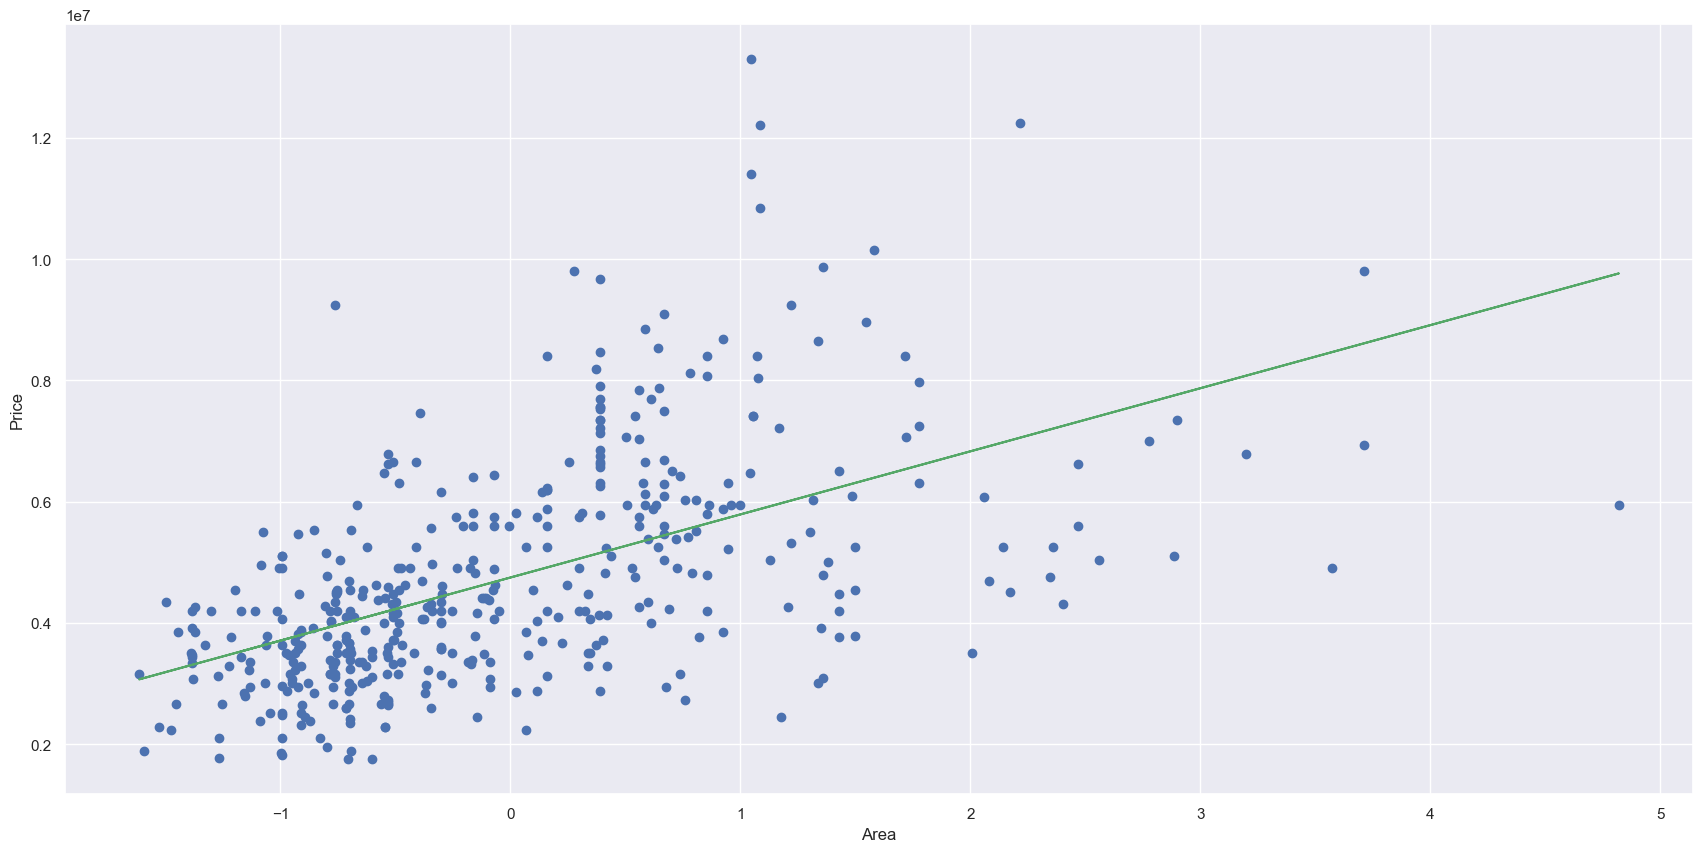

*************Evaluating performance of trained model on test partition*************
MAE: 1181677.5017588874
MSE: 2764797555900.765
RMSE: 1662768.0403173394
R2 SCore: 0.22098086489160718


In [21]:
features = ['area']   # Single feature

X = df[features].values
Y = df['price'].values.reshape((-1,1))

XScaled = normalize(X)

LinRegression(XScaled, Y)

In [22]:
from sklearn.preprocessing import PolynomialFeatures
# Switch back to MULTIVARIATE
features = df.columns[1:]

X = df[features].values
Y = df['price'].values.reshape((-1,1))

XScaled = normalize(X)


def PolyRegression(XScaled, Y, degree):

    print("*************Polynomial Regression (Degree =", degree, ")*************")

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(XScaled)

    print("New Shape After Polynomial Transformation:", X_poly.shape)

    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(X_poly, Y, seed=2, splitRatio=0.2)

    print("*************K-Fold Cross Validation*************")
    from sklearn.model_selection import KFold

    kf = KFold(n_splits=5, shuffle=True, random_state=2)

    mse_list = []
    r2_list = []

    for train_index, test_index in kf.split(X_poly):

        X_train_k = X_poly[train_index]
        X_test_k = X_poly[test_index]
        Y_train_k = Y[train_index]
        Y_test_k = Y[test_index]

        model_k = LinearRegression()
        model_k.fit(X_train_k, Y_train_k)

        Y_pred_k = model_k.predict(X_test_k)

        mse_list.append(metrics.mean_squared_error(Y_test_k, Y_pred_k))
        r2_list.append(metrics.r2_score(Y_test_k, Y_pred_k))

    print("Average K-Fold MSE:", np.mean(mse_list))
    print("Average K-Fold R2:", np.mean(r2_list))

    print("*************Training Final Model*************")
    model = LinearRegression()
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    print("*************Test Performance*************")
    print('MSE:', metrics.mean_squared_error(Y_test, Y_pred))
    print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
    print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean and Standard Deviation Before
[5.15054128e+03 2.96513761e+00 1.28623853e+00 1.80550459e+00
 8.58715596e-01 1.77981651e-01 3.50458716e-01 4.58715596e-02
 3.15596330e-01 6.93577982e-01 2.34862385e-01 9.30275229e-01] [2.16814915e+03 7.37386427e-01 5.02008423e-01 8.66696233e-01
 3.48314687e-01 3.82497298e-01 4.77113618e-01 2.09206500e-01
 4.64752931e-01 8.60794942e-01 4.23912780e-01 7.60673843e-01]
Mean and Standard Deviation After
[-0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0.  0.] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:
PolyRegression(XScaled, Y, degree=2)

*************Polynomial Regression (Degree = 2 )*************
New Shape After Polynomial Transformation: (545, 91)
*************Train-Test Split*************
Dimensions of Original Data:
Size(X): (545, 91) ; Size(Y) (545, 1)
Dimensions of Training Data:
Size(X_train): (436, 91) ; Size(Y_train) (436, 1)
Dimensions of Test Data:
Size(X_test): (109, 91) ; Size(Y_test) (109, 1)
*************K-Fold Cross Validation*************
Average K-Fold MSE: 1929255738409.3843
Average K-Fold R2: 0.4456570939306556
*************Training Final Model*************
*************Test Performance*************
MSE: 2040661908262.8179
RMSE: 1428517.3811553074
R2 Score: 0.42501588536538715


In [24]:
from sklearn.linear_model import Ridge, Lasso

def RegularizedPolyRegression(XScaled, Y, degree):

    print("*************Polynomial + Regularization (Degree =", degree, ")*************")

    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(XScaled)

    print("New Shape After Polynomial Transformation:", X_poly.shape)

    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(X_poly, Y, seed=2, splitRatio=0.2)

    # ================= RIDGE =================
    print("\n*************Ridge Regression*************")

    ridge = Ridge(alpha=1.0)

    ridge.fit(X_train, Y_train)
    Y_pred_ridge = ridge.predict(X_test)

    print("Test MSE:", metrics.mean_squared_error(Y_test, Y_pred_ridge))
    print("Test RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_ridge)))
    print("Test R2:", metrics.r2_score(Y_test, Y_pred_ridge))

    # ================= LASSO =================
    print("\n*************Lasso Regression*************")

    lasso = Lasso(alpha=50, max_iter=200000)

    lasso.fit(X_train, Y_train)
    Y_pred_lasso = lasso.predict(X_test)

    print("Test MSE:", metrics.mean_squared_error(Y_test, Y_pred_lasso))
    print("Test RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_lasso)))
    print("Test R2:", metrics.r2_score(Y_test, Y_pred_lasso))

In [25]:
RegularizedPolyRegression(XScaled, Y, degree=2)

*************Polynomial + Regularization (Degree = 2 )*************
New Shape After Polynomial Transformation: (545, 91)
*************Train-Test Split*************
Dimensions of Original Data:
Size(X): (545, 91) ; Size(Y) (545, 1)
Dimensions of Training Data:
Size(X_train): (436, 91) ; Size(Y_train) (436, 1)
Dimensions of Test Data:
Size(X_test): (109, 91) ; Size(Y_test) (109, 1)

*************Ridge Regression*************
Test MSE: 2013299524220.5132
Test RMSE: 1418907.863189331
Test R2: 0.4327256074409318

*************Lasso Regression*************


Test MSE: 2034825241498.0103
Test RMSE: 1426473.0076303617
Test R2: 0.42666044523029745
